# **Нелинейные модели против южной погоды**

Автор: Мельников Артём Владимирович

Дата: 12.05.2026

## Цели и задачи проекта

Компания BikeSouth хочет улучшить систему прогнозирования спроса на аренду велосипедов. Текущая baseline-модель на основе линейной регрессии не справляется со сложными погодными зависимостями и не учитывает взаимодействие факторов между собой.

Цель проекта:
- построить более точную модель прогнозирования почасового спроса на велосипеды.

Основные задачи проекта:
- изучить качество baseline-модели на основе линейной регрессии;
- провести исследовательский анализ данных;
- подготовить данные для обучения моделей;
- обучить две нелинейные модели:
  - KNeighborsRegressor;
  - DecisionTreeRegressor;
- подобрать оптимальные гиперпараметры с помощью Optuna;
- сравнить модели по метрикам RMSE, MAE и R²;
- выбрать лучшую модель и проверить её качество на тестовой выборке;
- проанализировать важность признаков и сделать выводы для бизнеса.

Практическая цель проекта:
- повысить точность прогнозов спроса;
- снизить дефицит и простой велосипедов;
- помочь компании эффективнее распределять велосипеды между станциями проката.

## Описание данных

В проекте используются три файла:

- `baseline_linear_regression_pipeline.pkl` - готовый baseline-пайплайн с линейной регрессией;
- `ds_s14_train_data.csv` - данные для обучения и валидации моделей;
- `ds_s14_test_data.csv` - тестовая выборка для финальной проверки качества.

Целевая переменная:
- `Rented Bike Count` - количество арендованных велосипедов за конкретный час.

Описание признаков:

- `Temperature` - температура воздуха (°C);
- `Humidity` - влажность воздуха (%);
- `Windspeed` - скорость ветра (м/с);
- `Visibility` - видимость;
- `Dew Point Temperature` - температура точки росы (°C);
- `Solar Radiation` - солнечная радиация;
- `Rainfall` - количество осадков;
- `Snowfall` - количество снега;
- `Seasons` - время года;
- `Holiday` - праздничный или выходной день;
- `Functioning Day` - работала ли система проката;
- признаки временных периодов:
  - `Night`
  - `Morning`
  - `Evening`
  - `Late Evening`

Если все временные признаки имеют значение `False`, запись относится к периоду `Daytime`.

Каждая строка датасета описывает погодные и календарные условия в определённый час и соответствующий спрос на аренду велосипедов.

## План работы

### Часть 1. Анализ baseline-модели
- загрузить baseline-пайплайн;
- загрузить обучающую и тестовую выборки;
- разделить данные на признаки и целевую переменную;
- получить предсказания baseline-модели;
- оценить качество модели по метрикам RMSE, MAE и R².

### Часть 2. Исследовательский анализ данных
- изучить структуру данных;
- проверить типы данных и наличие пропусков;
- изучить распределение целевой переменной;
- исследовать влияние погодных и временных факторов на спрос;
- проанализировать корреляции между признаками.

### Часть 3. Подготовка данных
- разделить данные на признаки и целевую переменную;
- подготовить пайплайны предобработки;
- выполнить масштабирование числовых признаков для kNN;
- подготовить данные для кросс-валидации.

### Часть 4. Обучение моделей
- обучить базовую модель kNN;
- обучить базовую модель дерева решений;
- проверить корректность работы пайплайнов.

### Часть 5. Подбор гиперпараметров
- настроить Optuna для kNN;
- настроить Optuna для дерева решений;
- подобрать лучшие гиперпараметры по метрике RMSE.

### Часть 6. Оценка моделей
- провести кросс-валидацию лучших моделей;
- сравнить результаты baseline, kNN и дерева решений;
- визуализировать результаты и стабильность моделей.

### Часть 7. Финальная оценка и выводы
- выбрать лучшую модель;
- проверить её качество на тестовой выборке;
- сравнить результаты с baseline-моделью;
- проанализировать важность признаков;
- сформулировать выводы и рекомендации для бизнеса.

### Дополнительное задание
- реализовать кастомный трансформер;
- встроить его в sklearn pipeline;
- проверить влияние новых признаков на качество модели.

# Структура проекта

## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл — готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново — достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² — эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

>Техническая напоминание: для работы с PKL-файлом нужно установить библиотеку joblib.

# Подготовка среды и библиотек

Перед началом работы подготовим окружение: установим нужные библиотеки, импортируем их и зафиксируем список зависимостей в файл `requirements.txt`.

Импорты оформим через `try except`, чтобы сразу увидеть, какой библиотеки не хватает, если окружение настроено не полностью.

In [1]:
# Установка совместимых версий библиотек
!pip install -q \
numpy==1.26.4 \
pandas==2.2.2 \
scikit-learn==1.6.1 \
matplotlib \
seaborn \
joblib \
optuna \
phik

In [103]:
# Подключим библиотеки через try|except, чтобы ничего не упало
try:
    import joblib
    import optuna
    import warnings

    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    from phik.report import plot_correlation_matrix

    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    from sklearn.preprocessing import (
        OneHotEncoder,
        RobustScaler
    )

    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.tree import DecisionTreeRegressor

    from sklearn.model_selection import (
        KFold,
        cross_val_score,
        cross_validate
    )

    from sklearn.metrics import (
        mean_squared_error,
        mean_absolute_error,
        r2_score
    )

    from sklearn.inspection import permutation_importance
    
    # Импорт визуализаций Optuna
    from optuna.visualization import matplotlib as opt_mpl
    
    from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

    print('Все библиотеки успешно импортированы')

except ImportError as error:
    print(f'Ошибка импорта: {error}')

Все библиотеки успешно импортированы


In [3]:
# Сохраняем список установленных библиотек
!pip freeze > requirements.txt

**Базовые настройки проекта**

In [4]:
# Константы проекта
RANDOM_STATE = 42
CV_SPLITS = 5
N_JOBS = -1 # задействуем все ядра для вычислений

# Настройки отображения pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', None)

# Формат отображения чисел
pd.set_option('display.float_format', lambda value: f'{value:.4f}')

# Настройки стиля графиков
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

# тема
sns.set_theme(
    style='whitegrid',
    palette='muted'
)

sns.set_context('notebook')

# Параметры отображения matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Отображение графиков внутри ноутбука
%matplotlib inline

# Отключение предупреждений
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Настройки отображения успешно применены')

Настройки отображения успешно применены


In [5]:
# Вспомогательная функция для подписей над столбцами на графиках

def add_bar_labels(ax, fmt="{:.3f}", offset=0.0):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height + offset),
            ha="center",
            va="bottom"
        )

В первой части проекта необходимо познакомиться с baseline-моделью, которую ранее использовала компания BikeSouth. Заказчик предоставил готовый обученный пайплайн с линейной регрессией и два датасета: обучающий и тестовый.

На этом этапе модель переобучать не требуется. Основная задача - загрузить готовый `.pkl`-пайплайн, проверить корректность его работы и оценить качество прогнозов с помощью метрик регрессии.

Для оценки baseline-модели будут использоваться:
- RMSE;
- MAE;
- R².

Эти результаты в дальнейшем станут точкой отсчёта для сравнения с более сложными нелинейными моделями.

**Загрузка данных**

Создадим небольшую функцию для загрузки датасетов. Она сначала попытается найти файл локально, а если это не получится - загрузит его по ссылке.

In [6]:
def read_data(file_name):
    """
    Загружает датасет локально или из облачного хранилища.
    """
    
    local_path = f'/datasets/{file_name}'
    cloud_path = f'https://code.s3.yandex.net/datasets/{file_name}'
    
    try:
        data = pd.read_csv(local_path)
        print(f'Файл {file_name} успешно загружен локально')
        return data
    
    except FileNotFoundError:
        
        try:
            data = pd.read_csv(cloud_path)
            print(f'Файл {file_name} успешно загружен из облака')
            return data
        
        except Exception as error:
            print(f'Ошибка при загрузке файла {file_name}: {error}')
            return None

In [7]:
# Загружаем обучающую и тестовую выборки
train_data = read_data('ds_s14_train_data.csv')
test_data = read_data('ds_s14_test_data.csv')

display(train_data.head())
test_data.head()

Файл ds_s14_train_data.csv успешно загружен локально
Файл ds_s14_test_data.csv успешно загружен локально


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3000,35.0000,2.4000,2000.0000,4.3000,0.4600,0.0000,0.0000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4000,55.0000,3.2000,2000.0000,15.6000,0.1500,0.0000,0.0000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9000,39.0000,1.6000,2000.0000,-18.5000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2000,37.0000,2.2000,2000.0000,-17.6000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4000,34.0000,2.1000,2000.0000,6.6000,2.8400,0.0000,0.0000,Autumn,No Holiday,Yes,False,False,False,False,1686


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7000,48.0000,0.8000,817.0000,-3.5000,0.3900,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3000,90.0000,1.1000,311.0000,-6.6000,0.0000,0.0000,2.2000,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9000,66.0000,1.2000,173.0000,-2.8000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1000,63.0000,2.6000,949.0000,15.6000,1.6800,0.0000,0.0000,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3000,43.0000,1.2000,1257.0000,10.0000,1.9100,0.0000,0.0000,Summer,No Holiday,Yes,False,False,True,False,1005


**Загрузка baseline-модели**

Компания предоставила готовый pipeline с линейной регрессией. Загрузим его с помощью `joblib`.

In [8]:
baseline_pipeline = joblib.load('baseline_linear_regression_pipeline.pkl')

**Подготовка данных для baseline-модели**

In [9]:
# Название целевого признака
TARGET = 'Rented Bike Count'

# Разделение обучающей выборки
X_train = train_data.drop(columns=[TARGET])
y_train = train_data[TARGET]

# Разделение тестовой выборки
X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

**Проверка качества baseline-модели**

Получим предсказания baseline-модели и оценим качество с помощью метрик RMSE, MAE и R².

In [10]:
# Предсказания baseline-модели
baseline_predictions = baseline_pipeline.predict(X_test)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f'RMSE: {baseline_rmse:.2f}')
print(f'MAE: {baseline_mae:.2f}')
print(f'R²: {baseline_r2:.2f}')

RMSE: 411.56
MAE: 312.60
R²: 0.59


**Промежуточный вывод**

Baseline-модель на основе линейной регрессии показывает среднее качество прогнозирования. Значение RMSE остаётся достаточно высоким, это говорит о том, что модель допускает достаточно крупные ошибки при прогнозировании спроса, что может приводить к неравномерному распределению велосипедов между станциями.

Это ожидаемый результат, поскольку линейная регрессия плохо справляется со сложными нелинейными зависимостями между погодными условиями и спросом. Вероятно, модель не может полноценно учитывать влияние сочетаний признаков, например температуры, влажности и осадков одновременно.

Далее будут исследованы более гибкие нелинейные модели - kNN и дерево решений.

## **Часть 2. Улучшение модели — kNN и дерево решений**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.

Линейная регрессия дала базовое понимание качества прогнозирования, но её возможностей недостаточно для сложных погодных зависимостей. Теперь попробуем более гибкие алгоритмы, которые способны учитывать нелинейные взаимосвязи между признаками.

На этом этапе основной акцент будет сделан на двух моделях:
- KNeighborsRegressor;
- DecisionTreeRegressor.

Перед обучением моделей необходимо внимательно изучить данные:
- проверить качество данных;
- оценить распределения признаков;
- найти потенциальные выбросы;
- посмотреть, какие факторы сильнее всего связаны со спросом на велосипеды.

### 5.1 Исследовательский анализ данных (EDA)

Начнём с общего знакомства с датасетом: посмотрим на структуру данных, типы признаков, наличие пропусков и распределение целевой переменной.

In [11]:
# Размер датасета
print(f'Размер обучающей выборки: {train_data.shape}')

Размер обучающей выборки: (7008, 16)


In [12]:
# Общая информация о датасете
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [13]:
# Первые строки датасета
display(train_data.head())

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3000,35.0000,2.4000,2000.0000,4.3000,0.4600,0.0000,0.0000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4000,55.0000,3.2000,2000.0000,15.6000,0.1500,0.0000,0.0000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9000,39.0000,1.6000,2000.0000,-18.5000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2000,37.0000,2.2000,2000.0000,-17.6000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4000,34.0000,2.1000,2000.0000,6.6000,2.8400,0.0000,0.0000,Autumn,No Holiday,Yes,False,False,False,False,1686


**Проверка дубликатов**

In [14]:
# Проверяем наличие полных дубликатов
duplicates_count = train_data.duplicated().sum()

print(f'Количество полных дубликатов: {duplicates_count}')

Количество полных дубликатов: 0


**Анализ пропусков**

Проверим данные на пропущенные значения, пустые строки и возможные текстовые артефакты.

In [15]:
def missing_report(dataframe):
    """
    Возвращает таблицу с информацией о пропусках.
    """

    missing_stats = {}

    for column in dataframe.columns:

        missing_count = dataframe[column].isna().sum()

        if dataframe[column].dtype == 'object':

            column_as_string = dataframe[column].astype(str)

            missing_count += (column_as_string == '').sum()
            missing_count += column_as_string.str.isspace().sum()

            missing_count += (
                column_as_string.str.lower().isin(['nan', 'none'])
            ).sum()

        if missing_count > 0:

            missing_stats[column] = {
                'missing_count': missing_count,
                'missing_percent': round(
                    missing_count / len(dataframe) * 100,
                    2
                )
            }

    if not missing_stats:
        print('Пропусков не обнаружено')

    else:
        missing_df = pd.DataFrame(missing_stats).T
        display(
            missing_df.sort_values(
                by='missing_count',
                ascending=False
            )
        )
        
# проверяем пропуски
missing_report(train_data)

,missing_count,missing_percent
Snowfall (cm),263.0000,3.7500
Rainfall(mm),262.0000,3.7400
Visibility (10m),259.0000,3.7000
Humidity(%),250.0000,3.5700
Wind speed (m/s),210.0000,3.0000
Solar Radiation (MJ/m2),210.0000,3.0000


**Описание числовых признаков**

Посмотрим на основные статистики числовых признаков, чтобы оценить диапазоны значений и возможные выбросы.

In [16]:
display(
    train_data.describe(
        include=[np.number],
        percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
    ).T
)

,count,mean,std,min,25%,50%,75%,95%,99%,max
Temperature,7008.0000,12.8129,11.9247,-17.5000,3.3000,13.5000,22.4000,30.7000,35.1000,39.4000
Humidity(%),6758.0000,58.2005,20.3403,0.0000,42.0000,57.0000,74.0000,94.0000,97.0000,98.0000
Wind speed (m/s),6798.0000,1.7252,1.0430,0.0000,0.9000,1.5000,2.3000,3.7000,4.7000,7.4000
Visibility (10m),6749.0000,1435.1568,607.2910,27.0000,936.0000,1691.0000,2000.0000,2000.0000,2000.0000,2000.0000
Dew point temperature,7008.0000,4.0215,13.0334,-30.6000,-4.7000,5.0000,14.8000,22.5000,24.7000,26.8000
Solar Radiation (MJ/m2),6798.0000,0.5699,0.8661,0.0000,0.0000,0.0100,0.9400,2.5500,3.1500,3.5200
Rainfall(mm),6746.0000,0.1469,1.1641,0.0000,0.0000,0.0000,0.0000,0.2000,4.0000,35.0000
Snowfall (cm),6745.0000,0.0748,0.4382,0.0000,0.0000,0.0000,0.0000,0.2000,2.5000,8.8000
Rented Bike Count,7008.0000,705.6060,646.3118,0.0000,190.7500,504.5000,1070.0000,2053.6000,2554.0400,3556.0000


**Описание категориальных признаков**

In [17]:
display(
    train_data.describe(include=['object']).T
)

,count,unique,top,freq
Seasons,7008,4,Autumn,1770
Holiday,7008,2,No Holiday,6668
Functioning Day,7008,2,Yes,6766


**Анализ распределения числовых признаков**

Сначала посмотрим на выбросы через boxplot, а затем изучим распределения признаков с помощью гистограмм.

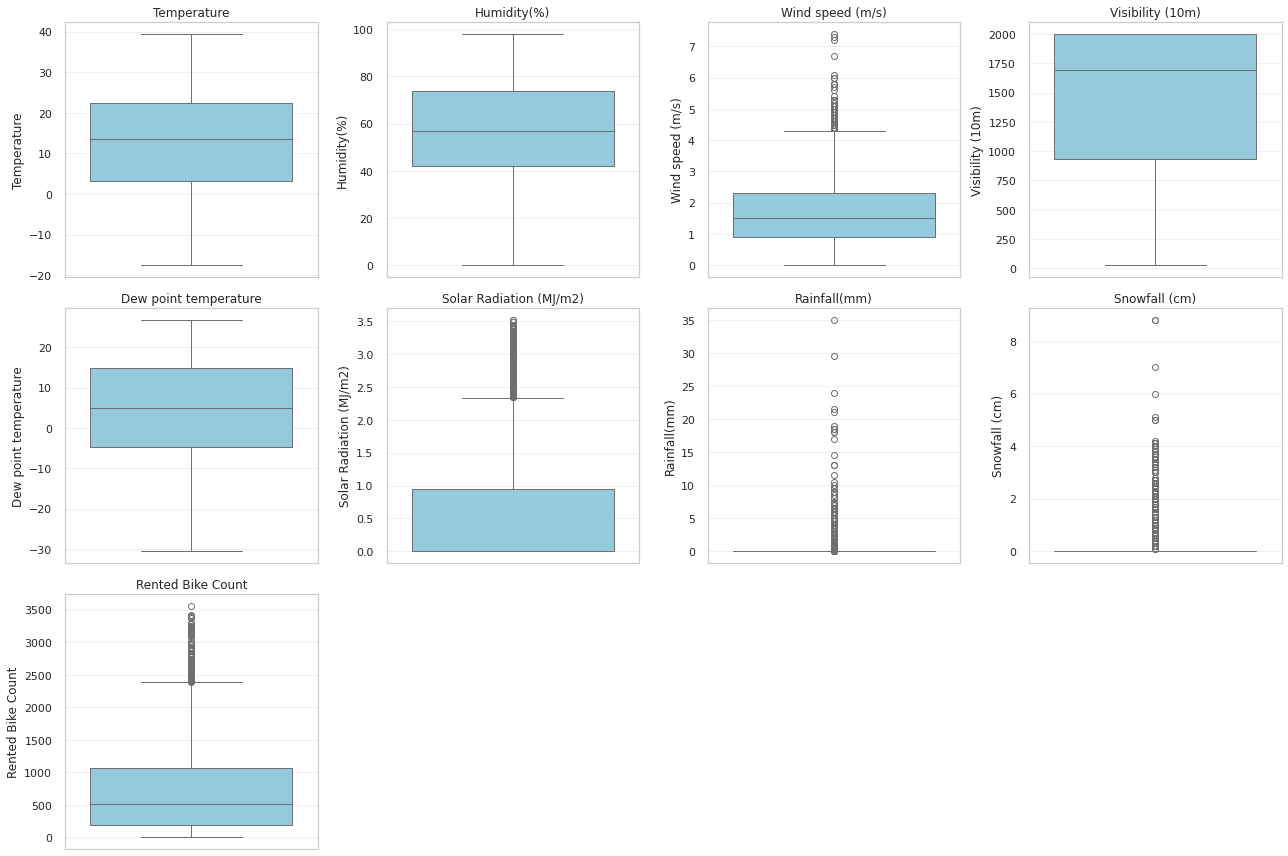

In [18]:
# Список числовых признаков
numeric_features = train_data.select_dtypes(
    include=[np.number]
).columns.tolist()

# Количество графиков в строке
plots_per_row = 4

rows_count = (
    len(numeric_features) - 1
) // plots_per_row + 1

plt.figure(figsize=(18, 4 * rows_count))

for index, feature in enumerate(numeric_features, start=1):

    plt.subplot(rows_count, plots_per_row, index)

    sns.boxplot(
        y=train_data[feature],
        color='skyblue'
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

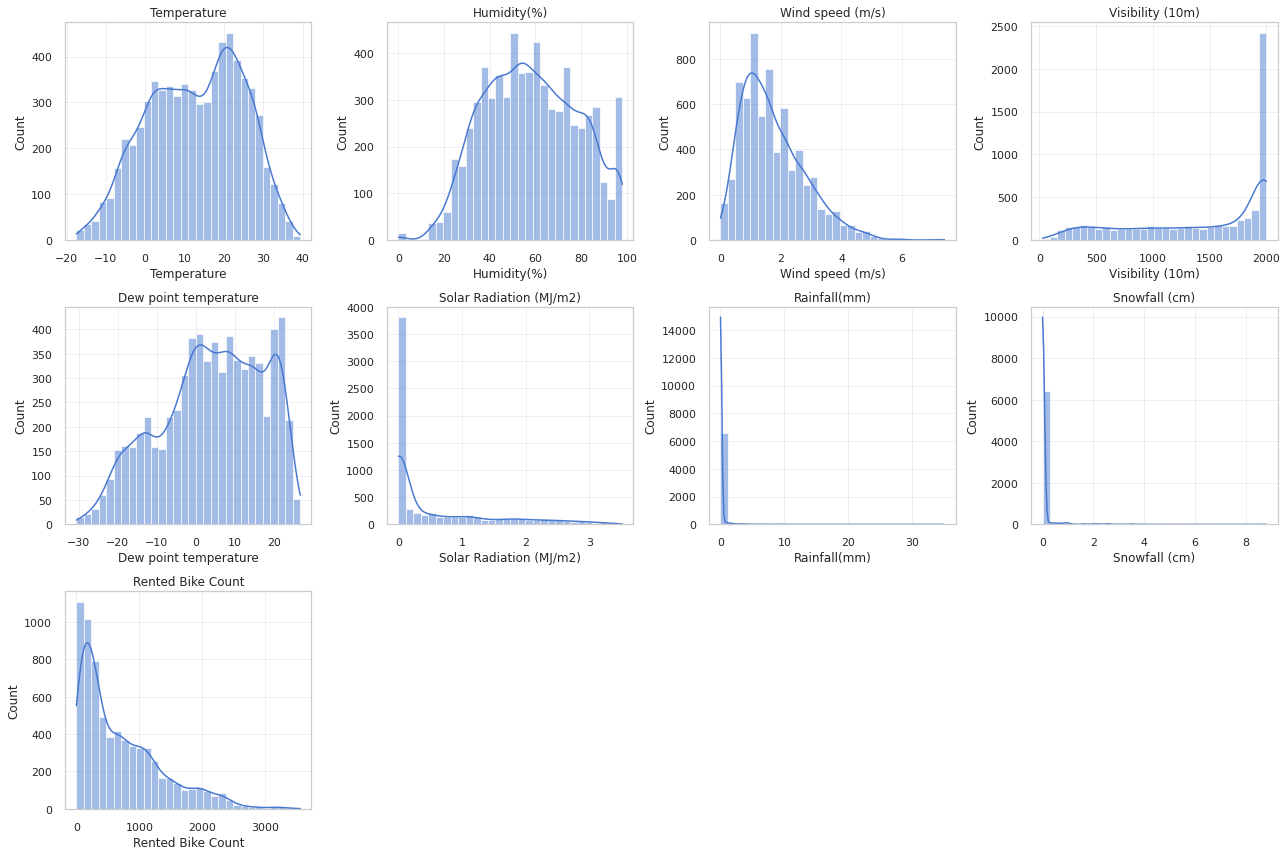

In [19]:
# Гистограммы числовых признаков
plt.figure(figsize=(18, 4 * rows_count))

for index, feature in enumerate(numeric_features, start=1):

    plt.subplot(rows_count, plots_per_row, index)

    sns.histplot(
        train_data[feature],
        kde=True,
        bins=30
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

**Анализ целевой переменной**

Посмотрим, как распределён спрос на аренду велосипедов.

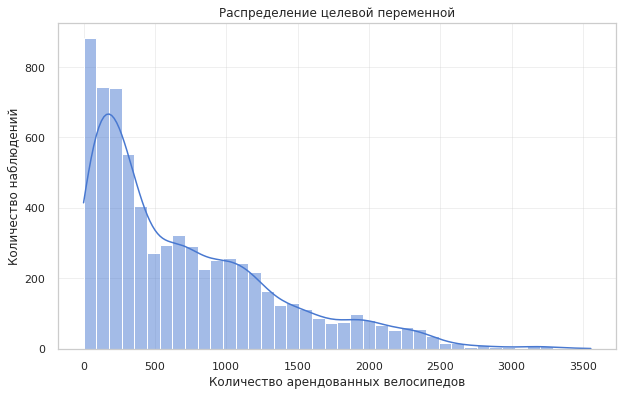

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train_data[TARGET],
    bins=40,
    kde=True
)

plt.title('Распределение целевой переменной')
plt.xlabel('Количество арендованных велосипедов')
plt.ylabel('Количество наблюдений')

plt.show()

In [21]:
# Основные статистики целевой переменной
train_data[TARGET].describe()

count   7008.0000
mean     705.6060
std      646.3118
min        0.0000
25%      190.7500
50%      504.5000
75%     1070.0000
max     3556.0000
Name: Rented Bike Count, dtype: float64

Среднее значение спроса составляет около 706 арендованных велосипедов за час, однако медиана заметно ниже - около 505. Это подтверждает, что распределение смещено вправо: относительно небольшое количество часов с очень высоким спросом заметно поднимает среднее значение.

Максимальное значение достигает 3556 аренд за час, что значительно превышает 99-й перцентиль. Такие пики могут быть связаны с вечерними часами, хорошей погодой или сезонным спросом летом и осенью.

**Влияние сезона на спрос**

Проверим, как меняется среднее количество аренд в зависимости от времени года.

In [22]:
season_demand = (
    train_data
    .groupby('Seasons')[TARGET]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(season_demand)

,Seasons,Rented Bike Count
0,Summer,1046.2471
1,Autumn,820.6441
2,Spring,725.0461
3,Winter,226.4176


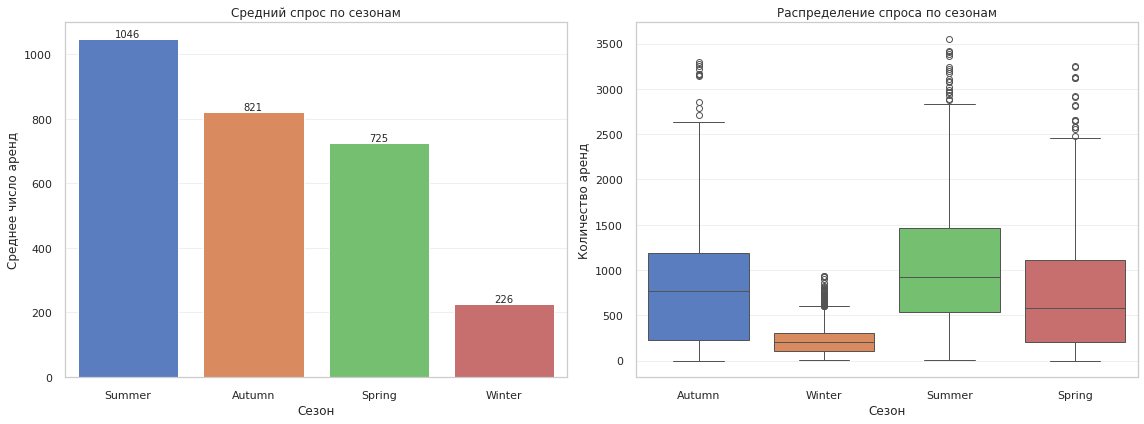

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Средний спрос по сезонам
sns.barplot(
    data=season_demand,
    x='Seasons',
    y=TARGET,
    hue='Seasons',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Средний спрос по сезонам')
axes[0].set_xlabel('Сезон')
axes[0].set_ylabel('Среднее число аренд')

add_bar_labels(axes[0], fmt='{:.0f}')

# Распределение спроса по сезонам
sns.boxplot(
    data=train_data,
    x='Seasons',
    y=TARGET,
    hue='Seasons',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Распределение спроса по сезонам')
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('Количество аренд')

plt.tight_layout()
plt.show()

Средний спрос летом почти в 4.6 раза выше, чем зимой:
- Summer - ~1046 аренд;
- Winter - ~226 аренд.

Это говорит о крайне сильной сезонности и высокой зависимости бизнеса от погодных условий.

**Анализ спроса по времени суток**

В исходных данных время суток закодировано через несколько бинарных колонок. Для удобства анализа создадим отдельный категориальный признак.

In [24]:
# Создаём копию датасета для EDA
eda_data = train_data.copy()

time_features = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

# Восстанавливаем категориальный признак времени суток
eda_data['Time_Period'] = (
    eda_data[time_features]
    .idxmax(axis=1)
    .str.replace('Time_Period_', '')
)

# Daytime определяется, когда все признаки False
daytime_mask = (
    eda_data[time_features].sum(axis=1) == 0
)

eda_data.loc[daytime_mask, 'Time_Period'] = 'Daytime'

In [25]:
time_demand = (
    eda_data
    .groupby('Time_Period')[TARGET]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(time_demand)

,Time_Period,Rented Bike Count
0,Evening,1193.9795
1,Late Evening,927.0494
2,Daytime,689.8703
3,Morning,644.3379
4,Night,288.6321


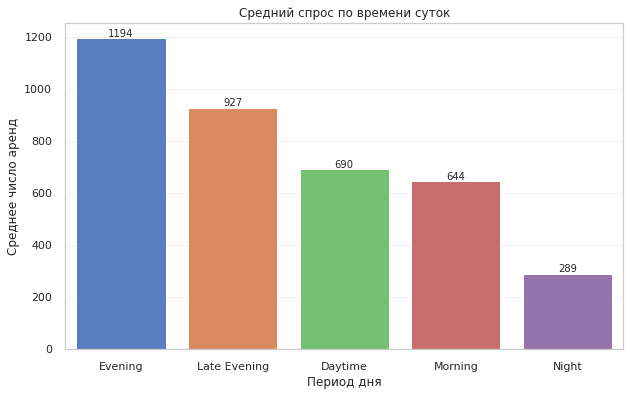

In [26]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=time_demand,
    x='Time_Period',
    y=TARGET,
    hue='Time_Period',
    legend=False
)

plt.title('Средний спрос по времени суток')
plt.xlabel('Период дня')
plt.ylabel('Среднее число аренд')

add_bar_labels(ax, fmt='{:.0f}')

plt.show()

**Влияние праздничных дней**

In [27]:
holiday_demand = (
    train_data
    .groupby('Holiday')[TARGET]
    .mean()
    .reset_index()
)

display(holiday_demand)

,Holiday,Rented Bike Count
0,Holiday,493.8794
1,No Holiday,716.4019


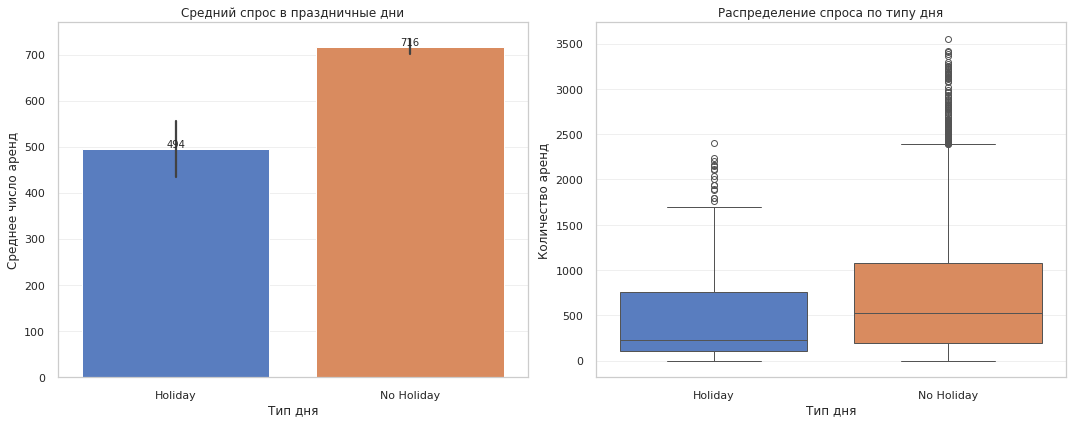

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Средний спрос по типу дня
sns.barplot(
    data=train_data,
    x='Holiday',
    y=TARGET,
    hue='Holiday',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Средний спрос в праздничные дни')
axes[0].set_xlabel('Тип дня')
axes[0].set_ylabel('Среднее число аренд')

# Подписи над столбиками
add_bar_labels(axes[0], fmt='{:.0f}')

# Распределение значений
sns.boxplot(
    data=train_data,
    x='Holiday',
    y=TARGET,
    hue='Holiday',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Распределение спроса по типу дня')
axes[1].set_xlabel('Тип дня')
axes[1].set_ylabel('Количество аренд')

plt.tight_layout()
plt.show()

**Количество уникальных значений**

Посмотрим, сколько уникальных значений есть в каждом признаке. Это поможет отделить числовые признаки от категориальных и бинарных, а также понять, какие признаки в дальнейшем нужно кодировать.

In [29]:
unique_summary = pd.DataFrame({
    'unique_count': train_data.nunique(),
    'dtype': train_data.dtypes
})

display(
    unique_summary.sort_values(
        by='unique_count',
        ascending=True
    )
)

,unique_count,dtype
Time_Period_Late Evening,2,bool
Time_Period_Evening,2,bool
Time_Period_Morning,2,bool
Time_Period_Night,2,bool
Functioning Day,2,object
Holiday,2,object
Seasons,4,object
Snowfall (cm),47,float64
Rainfall(mm),53,float64
Wind speed (m/s),64,float64


**Дополнительные признаки для EDA**

Для анализа восстановим общий признак `Time_Period` из бинарных колонок. Также создадим простые флаги осадков и сильного ветра. Это нужно только для исследования связей с целевой переменной.

Исходный датасет менять не будем, чтобы не нарушить дальнейшую подготовку данных.

In [30]:
# Копия данных только для исследовательского анализа
eda_data = train_data.copy()

time_period_columns = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

# Восстанавливаем общий признак времени суток
eda_data['Time_Period'] = (
    eda_data[time_period_columns]
    .idxmax(axis=1)
    .str.replace('Time_Period_', '')
)

# Если все временные признаки равны False, значит это Daytime
daytime_condition = eda_data[time_period_columns].sum(axis=1) == 0
eda_data.loc[daytime_condition, 'Time_Period'] = 'Daytime'

# Флаги наличия осадков
eda_data['has_rain'] = (eda_data['Rainfall(mm)'] >= 0.2).astype(int)
eda_data['has_snow'] = (eda_data['Snowfall (cm)'] >= 0.2).astype(int)

# Флаг сильного ветра по 95 процентилю
wind_threshold = eda_data['Wind speed (m/s)'].quantile(0.95)
eda_data['has_strong_wind'] = (
    eda_data['Wind speed (m/s)'] > wind_threshold
).astype(int)

display(eda_data.head())

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count,Time_Period,has_rain,has_snow,has_strong_wind
0,20.3000,35.0000,2.4000,2000.0000,4.3000,0.4600,0.0000,0.0000,Autumn,Holiday,Yes,True,False,False,False,1237,Evening,0,0,0
1,25.4000,55.0000,3.2000,2000.0000,15.6000,0.1500,0.0000,0.0000,Autumn,No Holiday,Yes,True,False,False,False,2468,Evening,0,0,0
2,-6.9000,39.0000,1.6000,2000.0000,-18.5000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,186,Late Evening,0,0,0
3,-5.2000,37.0000,2.2000,2000.0000,-17.6000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,True,254,Night,0,0,0
4,23.4000,34.0000,2.1000,2000.0000,6.6000,2.8400,0.0000,0.0000,Autumn,No Holiday,Yes,False,False,False,False,1686,Daytime,0,0,0


In [31]:
# Проверяем восстановленный признак времени суток
eda_data['Time_Period'].value_counts()

Time_Period
Night           1753
Daytime         1742
Late Evening    1173
Morning         1172
Evening         1168
Name: count, dtype: int64

**Связь осадков и сильного ветра со спросом**

Проверим, как меняется средний спрос при наличии дождя, снега и сильного ветра.

In [32]:
weather_flags = [
    'has_rain',
    'has_snow',
    'has_strong_wind'
]

weather_flag_summary = (
    eda_data
    .groupby(weather_flags)[TARGET]
    .mean()
    .reset_index()
)

display(weather_flag_summary)

,has_rain,has_snow,has_strong_wind,Rented Bike Count
0,0,0,0,768.4206
1,0,0,1,648.9630
2,0,1,0,189.8028
3,0,1,1,153.7250
4,1,0,0,147.5692
5,1,0,1,234.9167
6,1,1,0,89.9286
7,1,1,1,89.5000


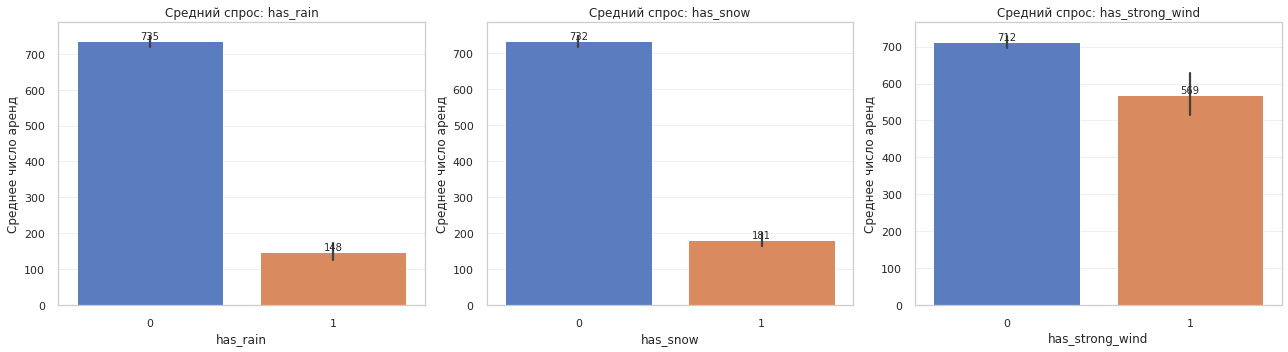

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for index, feature in enumerate(weather_flags):
    
    sns.barplot(
        data=eda_data,
        x=feature,
        y=TARGET,
        hue=feature,
        legend=False,
        ax=axes[index]
    )
    
    axes[index].set_title(f'Средний спрос: {feature}')
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel('Среднее число аренд')
    
    add_bar_labels(axes[index], fmt='{:.0f}')

plt.tight_layout()
plt.show()

Наличие дождя и снега резко снижает спрос на аренду велосипедов.

Например:
- без осадков средний спрос превышает 760 аренд;
- при наличии дождя спрос падает примерно до 148 аренд;
- сочетание дождя и снега даёт минимальные значения спроса - около 90 аренд.

Это подтверждает, что погодные условия оказывают сильное влияние на поведение пользователей и что бинарные признаки осадков действительно могут быть полезны для модели.

**Корреляционный анализ PhiK**

Для оценки связей между признаками используем PhiK. Этот метод удобен тем, что может работать не только с числовыми, но и с категориальными признаками.

Сначала построим матрицу связей между признаками, а затем отдельно посмотрим связь каждого признака с целевой переменной.

In [34]:
interval_columns = [
    TARGET,
    'Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

phik_corr = eda_data.phik_matrix(
    interval_cols=interval_columns
)

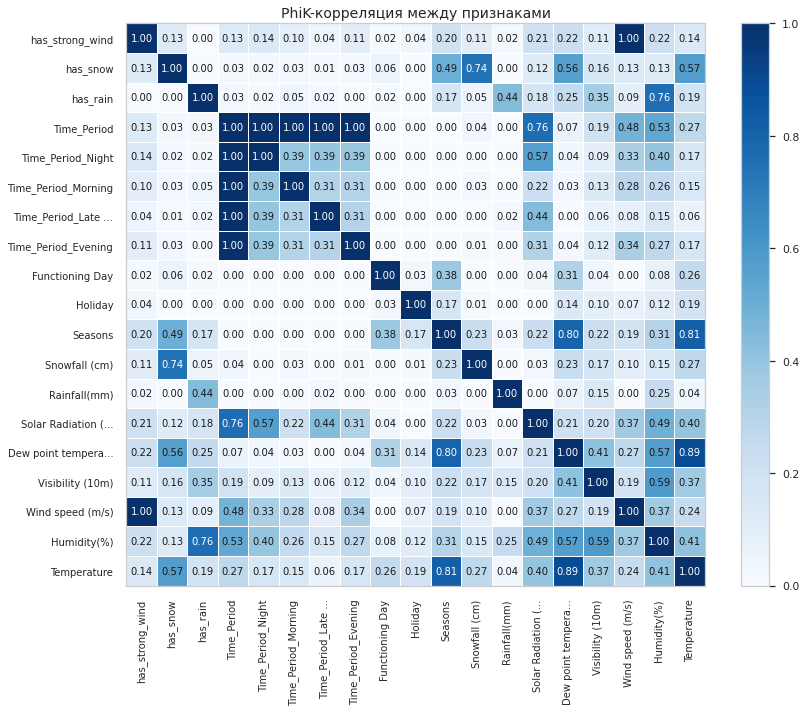

In [35]:
# Матрица связей между признаками без целевой переменной
phik_without_target = phik_corr.drop(
    index=TARGET,
    columns=TARGET
)

plot_correlation_matrix(
    phik_without_target.values,
    x_labels=phik_without_target.columns,
    y_labels=phik_without_target.index,
    vmin=0,
    vmax=1,
    color_map='Blues',
    title='PhiK-корреляция между признаками',
    fontsize_factor=1.0,
    figsize=(12, 10)
)

plt.show()

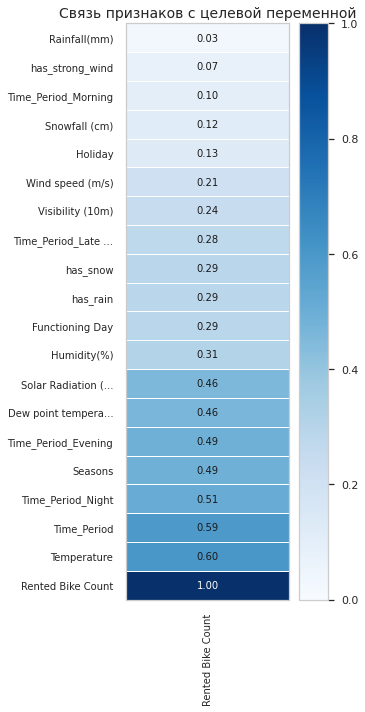

In [36]:
# Связь признаков с целевой переменной
phik_with_target = (
    phik_corr[[TARGET]]
    .sort_values(by=TARGET, ascending=False)
)

plot_correlation_matrix(
    phik_with_target.values,
    x_labels=[TARGET],
    y_labels=phik_with_target.index,
    vmin=0,
    vmax=1,
    color_map='Blues',
    title='Связь признаков с целевой переменной',
    fontsize_factor=1.0,
    figsize=(5, 10)
)

plt.show()

**Выводы по исследовательскому анализу**

В обучающей выборке 7008 строк и 16 столбцов. Полных дубликатов не обнаружено.

Целевая переменная `Rented Bike Count` имеет широкий диапазон значений: от 0 до 3556 арендованных велосипедов за час. Среднее значение составляет около 706, а медиана - около 505. Это говорит о смещении распределения вправо: чаще встречаются небольшие и средние значения спроса, но есть отдельные часы с очень высоким спросом.

В данных есть пропуски в погодных числовых признаках:

- `Snowfall (cm)` - 263 пропуска;
- `Rainfall(mm)` - 262 пропуска;
- `Visibility (10m)` - 259 пропусков;
- `Humidity(%)` - 250 пропусков;
- `Wind speed (m/s)` - 210 пропусков;
- `Solar Radiation (MJ/m2)` - 210 пропусков.

Доля пропусков небольшая, примерно 3-4%, но перед обучением моделей их нужно обработать. Модели kNN и дерева решений из sklearn не работают с пропущенными значениями напрямую.

Сезонность выражена сильно. Средний спрос летом составляет около 1046 аренд, а зимой - около 226. То есть летом спрос почти в 4.6 раза выше, чем зимой. Это подтверждает, что `Seasons` является важным признаком для прогноза.

Время суток также сильно влияет на спрос. Самый высокий средний спрос наблюдается вечером - около 1194 аренд, а самый низкий ночью - около 289. Вечером спрос более чем в 4 раза выше, чем ночью, поэтому признаки `Time_Period_*` стоит обязательно сохранить в модели.

Праздничные дни могут влиять на спрос, но этот фактор лучше рассматривать вместе с сезоном, погодой и временем суток.

Погодные условия заметно связаны со спросом. Без осадков средний спрос превышает 760 аренд, при наличии дождя падает примерно до 148, а при сочетании дождя и снега снижается примерно до 90. Это подтверждает, что для модели могут быть полезны бинарные признаки наличия осадков, например `has_rain` и `has_snow`.

PhiK-корреляция показывает наличие нелинейных связей между признаками и целевой переменной. Отдельно стоит отметить связь между `Temperature` и `Dew point temperature`: эти признаки физически связаны между собой. Для дерева решений это не должно быть критичной проблемой, но для kNN похожие признаки могут добавлять шум, поэтому их влияние можно проверить на этапе экспериментов.

**Рекомендации для дальнейшей предобработки**

По итогам EDA в дальнейшей работе нужно учесть несколько моментов.

1. Пропуски  
Пропущенные значения есть только в погодных числовых признаках. Их нужно заполнить внутри пайплайна, чтобы избежать утечки данных. В качестве базового варианта подойдёт медианное заполнение.

2. Категориальные признаки  
Признаки `Seasons`, `Holiday` и `Functioning Day` нужно закодировать. Для этого можно использовать One-Hot Encoding.

3. Временные признаки  
Бинарные колонки `Time_Period_*` уже содержат информацию о времени суток. Их можно оставить как отдельные признаки. Общий признак `Time_Period`, созданный для EDA, в модель отдельно добавлять не будем, чтобы не дублировать информацию.

4. Масштабирование  
Для kNN масштабирование обязательно, потому что модель рассчитывает расстояния между объектами. Для дерева решений масштабирование не требуется, так как деревья не чувствительны к масштабу признаков.

5. Дополнительные признаки  
Есть смысл проверить признаки наличия осадков:

- `has_rain`;
- `has_snow`.

Для спроса на велосипеды сам факт дождя или снега может быть важнее точного количества осадков.

6. Выбор моделей  
kNN может хорошо работать, если похожие погодные ситуации действительно дают похожий спрос. Дерево решений может быть особенно полезно, потому что умеет работать с условиями вида: "если вечер, тепло и нет дождя, спрос высокий".



---



**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---



На предыдущем этапе мы подробно изучили данные и выявили несколько важных моментов:

- в погодных признаках есть пропуски;
- спрос сильно зависит от сезона и времени суток;
- осадки резко снижают количество аренд;
- для kNN масштаб признаков будет критически важен.

Теперь подготовим данные для обучения моделей. На этом этапе тестовую выборку использовать нельзя - она понадобится только для финальной проверки качества лучшей модели.

Основная задача сейчас:
- обработать пропуски;
- подготовить признаки;
- собрать пайплайны для kNN и дерева решений;
- провести первую проверку качества моделей до оптимизации гиперпараметров.

**Подготовка копии обучающего датасета**

Создадим рабочую копию обучающей выборки. Исходный `train_data` оставим без изменений.

In [37]:
# Создаём рабочую копию обучающего датасета
model_data = train_data.copy()

print(f'Размер рабочего датасета: {model_data.shape}')

Размер рабочего датасета: (7008, 16)


**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



Перед подбором гиперпараметров сначала проверим, что пайплайны работают корректно.

На этом шаге:

- обработаем пропуски;
- создадим дополнительные признаки;
- подготовим несколько вариантов датасета;
- соберём пайплайны для kNN и дерева решений;
- сравним базовые модели с baseline-линейной регрессией.

**Заполнение пропусков**

Большинство пропусков заполним медианой по сезону. Для `Solar Radiation (MJ/m2)` дополнительно учтём время суток, потому что солнечная радиация сильно зависит от периода дня.

In [38]:
# Признаки для заполнения медианой по сезону
season_fill_features = [
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

# Признаки, зависящие от сезона и времени суток
time_sensitive_features = [
    'Solar Radiation (MJ/m2)'
]

In [39]:
# Восстанавливаем Time_Period для заполнения пропусков
time_columns = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

model_data['Time_Period'] = (
    model_data[time_columns]
    .idxmax(axis=1)
    .str.replace('Time_Period_', '')
)

# Если все False -> Daytime
daytime_mask = (
    model_data[time_columns].sum(axis=1) == 0
)

model_data.loc[daytime_mask, 'Time_Period'] = 'Daytime'

In [40]:
# Заполняем пропуски медианой по сезону
for feature in season_fill_features:
    
    model_data[feature] = (
        model_data[feature]
        .fillna(
            model_data
            .groupby('Seasons')[feature]
            .transform('median')
        )
    )

In [41]:
# Заполняем Solar Radiation медианой по сезону и времени суток
for feature in time_sensitive_features:
    
    model_data[feature] = (
        model_data[feature]
        .fillna(
            model_data
            .groupby(
                ['Seasons', 'Time_Period']
            )[feature]
            .transform('median')
        )
    )

In [42]:
# Проверяем остаток пропусков
missing_report(model_data)

Пропусков не обнаружено


**Создание дополнительных признаков**

Создадим признаки уровня осадков:

- `rain_level`;
- `snow_level`.

Значения будут такими:

- 0 - осадков нет;
- 1 - обычные осадки;
- 2 - сильные осадки.

Порог сильных осадков определим как 90-й перцентиль среди ненулевых значений.

In [43]:
# Порог сильного дождя
rain_limit = (
    model_data
    .loc[model_data['Rainfall(mm)'] > 0, 'Rainfall(mm)']
    .quantile(0.90)
)

snow_limit = (
    model_data
    .loc[model_data['Snowfall (cm)'] > 0, 'Snowfall (cm)']
    .quantile(0.90)
)

print(f'Порог сильного дождя: {rain_limit:.2f}')
print(f'Порог сильного снега: {snow_limit:.2f}')

Порог сильного дождя: 6.00
Порог сильного снега: 3.49


In [44]:
def precipitation_category(value, threshold):
    """
    Переводит количество осадков в категорию:
    0 - нет осадков,
    1 - обычные осадки,
    2 - сильные осадки.
    """
    
    if value == 0:
        return 0
    
    if value <= threshold:
        return 1
    
    return 2

In [45]:
# Создаём новые признаки
model_data['rain_level'] = (
    model_data['Rainfall(mm)']
    .apply(precipitation_category, threshold=rain_limit)
)

model_data['snow_level'] = (
    model_data['Snowfall (cm)']
    .apply(precipitation_category, threshold=snow_limit)
)

In [46]:
print('Распределение rain_level:')
display(model_data['rain_level'].value_counts().sort_index())

print('Распределение snow_level:')
display(model_data['snow_level'].value_counts().sort_index())

Распределение rain_level:


rain_level
0    6623
1     347
2      38
Name: count, dtype: int64

Распределение snow_level:


snow_level
0    6666
1     307
2      35
Name: count, dtype: int64

**Подготовка основного набора признаков**

В основном варианте оставим погодные признаки, но заменим исходные `Rainfall(mm)` и `Snowfall (cm)` на созданные уровни осадков.

Вспомогательный признак `Time_Period` удалим, потому что информация о времени суток уже есть в бинарных колонках `Time_Period_*`.

In [47]:
features_to_remove = [
    'Rainfall(mm)',
    'Snowfall (cm)',
    'Time_Period'
]

model_data = model_data.drop(columns=features_to_remove)

print('Удалённые признаки:')
print(features_to_remove)

print('\nТекущие признаки датасета:')
display(model_data.columns.tolist())

Удалённые признаки:
['Rainfall(mm)', 'Snowfall (cm)', 'Time_Period']

Текущие признаки датасета:


['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Seasons',
 'Holiday',
 'Functioning Day',
 'Time_Period_Evening',
 'Time_Period_Late Evening',
 'Time_Period_Morning',
 'Time_Period_Night',
 'Rented Bike Count',
 'rain_level',
 'snow_level']

**Подготовка полного набора признаков**

Для проверки создадим ещё один вариант данных - `model_data_full`. В нём оставим исходные признаки дождя и снега. Это поможет понять, теряет ли модель полезную информацию после замены осадков на категории.

In [48]:
model_data_full = train_data.copy()

model_data_full['Time_Period'] = (
    model_data_full[time_columns]
    .idxmax(axis=1)
    .str.replace('Time_Period_', '')
)

daytime_mask_full = model_data_full[time_columns].sum(axis=1) == 0
model_data_full.loc[daytime_mask_full, 'Time_Period'] = 'Daytime'

for feature in season_fill_features:
    model_data_full[feature] = (
        model_data_full[feature]
        .fillna(
            model_data_full
            .groupby('Seasons')[feature]
            .transform('median')
        )
    )

for feature in time_sensitive_features:
    model_data_full[feature] = (
        model_data_full[feature]
        .fillna(
            model_data_full
            .groupby(['Seasons', 'Time_Period'])[feature]
            .transform('median')
        )
    )

model_data_full = model_data_full.drop(columns=['Time_Period'])

missing_report(model_data_full)

Пропусков не обнаружено


**Подготовка минимального набора признаков для kNN**

Дополнительно проверим гипотезу: возможно, kNN будет работать лучше на более компактном наборе признаков.

Удалим признаки, которые могут частично дублировать информацию других колонок:

- `Dew point temperature`;
- `Solar Radiation (MJ/m2)`;
- `Humidity(%)`.

Так мы проверим, помогает ли снижение размерности улучшить качество kNN.

In [49]:
model_data_minimal = model_data.copy()

minimal_drop_features = [
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Humidity(%)'
]

model_data_minimal = model_data_minimal.drop(columns=minimal_drop_features)

print('Удалённые признаки для минимальной версии kNN:')
print(minimal_drop_features)

display(model_data_minimal.head())

Удалённые признаки для минимальной версии kNN:
['Dew point temperature', 'Solar Radiation (MJ/m2)', 'Humidity(%)']


,Temperature,Wind speed (m/s),Visibility (10m),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count,rain_level,snow_level
0,20.3000,2.4000,2000.0000,Autumn,Holiday,Yes,True,False,False,False,1237,0,0
1,25.4000,3.2000,2000.0000,Autumn,No Holiday,Yes,True,False,False,False,2468,0,0
2,-6.9000,1.6000,2000.0000,Winter,No Holiday,Yes,False,True,False,False,186,0,0
3,-5.2000,2.2000,2000.0000,Winter,No Holiday,Yes,False,False,False,True,254,0,0
4,23.4000,2.1000,2000.0000,Autumn,No Holiday,Yes,False,False,False,False,1686,0,0


**Списки признаков для пайплайнов**

In [50]:
numeric_columns = [
    'Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)'
]

numeric_columns_full = [
    'Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

numeric_columns_minimal = [
    'Temperature',
    'Wind speed (m/s)',
    'Visibility (10m)'
]

categorical_columns = [
    'Seasons',
    'Holiday',
    'Functioning Day'
]

binary_columns = [
    'Time_Period_Morning',
    'Time_Period_Evening',
    'Time_Period_Night',
    'Time_Period_Late Evening'
]

ordinal_columns = [
    'rain_level',
    'snow_level'
]

**Препроцессоры для моделей**

Для kNN используем масштабирование числовых признаков через `RobustScaler` и кодирование категориальных признаков через `OneHotEncoder`.

Для дерева решений масштабирование не требуется, поэтому кодируем только категориальные признаки.

In [51]:
knn_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            RobustScaler(),
            numeric_columns
        ),
        (
            'cat',
            OneHotEncoder(drop='first', sparse_output=False),
            categorical_columns
        )
    ],
    remainder='passthrough'
)

knn_full_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            RobustScaler(),
            numeric_columns_full
        ),
        (
            'cat',
            OneHotEncoder(drop='first', sparse_output=False),
            categorical_columns
        )
    ],
    remainder='passthrough'
)

knn_minimal_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            RobustScaler(),
            numeric_columns_minimal
        ),
        (
            'cat',
            OneHotEncoder(drop='first', sparse_output=False),
            categorical_columns
        )
    ],
    remainder='passthrough'
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(drop='first', sparse_output=False),
            categorical_columns
        )
    ],
    remainder='passthrough'
)

**Настройка кросс-валидации и метрик**

Для всех моделей используем одинаковую схему кросс-валидации на 5 фолдах. Основная метрика - RMSE.

In [52]:
# Метрики для cross_validate
metric_set = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

# Кросс-валидация
cv_strategy = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

**Сборка пайплайнов**

Соберём базовые пайплайны для моделей и сразу выведем их структуру.

In [53]:
# Пайплайн kNN
knn_pipeline = Pipeline([
    (
        'preprocessor',
        knn_preprocessor
    ),
    (
        'model',
        KNeighborsRegressor(
            n_neighbors=5
        )
    )
])
display(knn_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model', KNeighborsRegressor())])

In [54]:
knn_full_pipeline = Pipeline([
    (
        'preprocessor',
        knn_full_preprocessor
    ),
    (
        'model',
        KNeighborsRegressor(n_neighbors=5)
    )
])

display(knn_full_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model', KNeighborsRegressor())])

In [55]:
knn_minimal_pipeline = Pipeline([
    (
        'preprocessor',
        knn_minimal_preprocessor
    ),
    (
        'model',
        KNeighborsRegressor(n_neighbors=5)
    )
])

display(knn_minimal_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['Temperature',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model', KNeighborsRegressor())])

In [56]:
# Пайплайн дерева решений
tree_pipeline = Pipeline([
    (
        'preprocessor',
        tree_preprocessor
    ),
    (
        'model',
        DecisionTreeRegressor(random_state=RANDOM_STATE)
    )
])

display(tree_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

**Подготовка обучающих выборок**

Подготовим отдельные пары `X` и `y` для каждого варианта данных.

In [57]:
# Признаки и целевая переменная
X_model = model_data.drop(columns=[TARGET])
y_model = model_data[TARGET]

X_full = model_data_full.drop(columns=[TARGET])
y_full = model_data_full[TARGET]

X_minimal = model_data_minimal.drop(columns=[TARGET])
y_minimal = model_data_minimal[TARGET]

**Оценка baseline и базовых нелинейных моделей**

Проверим несколько вариантов:

- baseline-линейная регрессия;
- kNN с обработанными признаками осадков;
- kNN на полном наборе признаков;
- kNN на минимальном наборе признаков;
- дерево решений.

Так мы сможем оценить не только сами модели, но и влияние разных вариантов подготовки признаков.

In [58]:
evaluation_results = []
rmse_distribution = []


def evaluate_model(model_name, estimator, features, target):
    """
    Оценивает модель на кросс-валидации и сохраняет метрики.
    """
    
    print(f'Оцениваем модель: {model_name}')
    
    cv_scores = cross_validate(
        estimator,
        features,
        target,
        cv=cv_strategy,
        scoring=metric_set,
        n_jobs=N_JOBS
    )
    
    evaluation_results.append({
        'Model': model_name,
        'RMSE': -cv_scores['test_RMSE'].mean(),
        'RMSE_std': cv_scores['test_RMSE'].std(),
        'MAE': -cv_scores['test_MAE'].mean(),
        'R2': cv_scores['test_R2'].mean()
    })
    
    for fold_score in cv_scores['test_RMSE']:
        rmse_distribution.append({
            'Model': model_name,
            'RMSE': -fold_score
        })

In [59]:
evaluate_model(
    'Baseline Linear Regression',
    baseline_pipeline,
    X_train,
    y_train
)

evaluate_model(
    'kNN',
    knn_pipeline,
    X_model,
    y_model
)

evaluate_model(
    'kNN Full',
    knn_full_pipeline,
    X_full,
    y_full
)

evaluate_model(
    'kNN Minimal',
    knn_minimal_pipeline,
    X_minimal,
    y_minimal
)

evaluate_model(
    'Decision Tree',
    tree_pipeline,
    X_model,
    y_model
)

Оцениваем модель: Baseline Linear Regression
Оцениваем модель: kNN
Оцениваем модель: kNN Full
Оцениваем модель: kNN Minimal
Оцениваем модель: Decision Tree


In [60]:
# Итоговая таблица
baseline_comparison = (
    pd.DataFrame(evaluation_results)
    .sort_values(by='RMSE')
    .reset_index(drop=True)
)

display(baseline_comparison)

,Model,RMSE,RMSE_std,MAE,R2
0,kNN,324.9910,7.1174,218.0671,0.7467
1,kNN Full,328.1423,5.9598,219.6703,0.7418
2,kNN Minimal,352.6979,11.3609,233.4165,0.7016
3,Decision Tree,396.1878,14.2457,247.7536,0.6236
4,Baseline Linear Regression,413.9009,3.1444,310.0915,0.5894


**Визуальное сравнение RMSE по фолдам**

Посмотрим не только на средние значения RMSE, но и на разброс ошибки по фолдам. Это поможет оценить стабильность моделей.

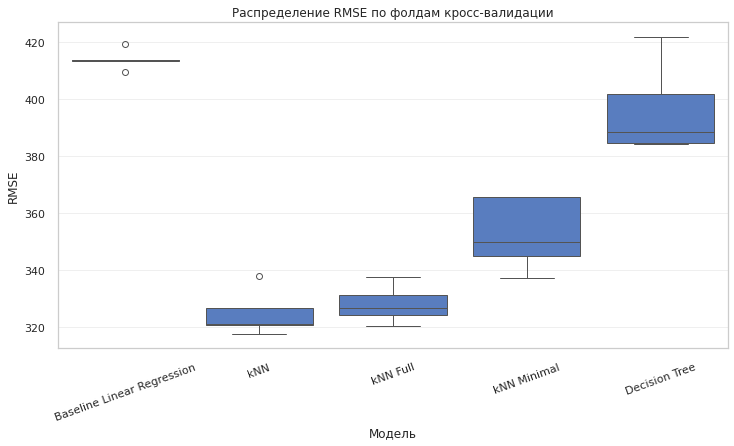

In [61]:
rmse_cv_data = pd.DataFrame(rmse_distribution)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=rmse_cv_data,
    x='Model',
    y='RMSE'
)

plt.title('Распределение RMSE по фолдам кросс-валидации')
plt.xlabel('Модель')
plt.ylabel('RMSE')
plt.xticks(rotation=20)

plt.show()

**Отчет о предобработке и выборе базовых моделей**

На этом этапе мы подготовили данные для первых экспериментов с нелинейными моделями.

**Обработка пропусков**

Пропуски в погодных признаках были заполнены с учётом структуры данных:

- `Humidity(%)`, `Wind speed (m/s)`, `Visibility (10m)`, `Rainfall(mm)` и `Snowfall (cm)` заполнены медианой по сезону;
- `Solar Radiation (MJ/m2)` заполнена медианой по сезону и времени суток.

Такой подход выбран потому, что погодные значения могут различаться по сезонам, а солнечная радиация дополнительно зависит от времени дня.

**Создание новых признаков**

Для осадков были созданы признаки:

- `rain_level`;
- `snow_level`.

Они показывают не точное количество осадков, а их уровень:

- 0 - осадков нет;
- 1 - обычные осадки;
- 2 - сильные осадки.

Это полезно для бизнеса, потому что для спроса на велосипеды часто важнее сам факт дождя или снега, а не точное количество миллиметров.

**3. Разные варианты kNN**

Для kNN были проверены три версии:

- `kNN` - основной вариант с созданными признаками осадков;
- `kNN Full` - полный набор признаков, включая исходные `Rainfall(mm)` и `Snowfall (cm)`;
- `kNN Minimal` - сокращённый набор признаков для проверки влияния похожих и потенциально избыточных колонок.

Такой эксперимент помогает понять, какие признаки действительно полезны для модели.

**4. Подготовка пайплайнов**

Для kNN использованы:

- `RobustScaler` для числовых признаков;
- `OneHotEncoder` для категориальных признаков.

Для дерева решений использован только `OneHotEncoder`, потому что деревьям не требуется масштабирование признаков.

**5. Первое сравнение моделей**

На базовых параметрах лучше всего себя показывает kNN. Это говорит о том, что похожие погодные и временные ситуации действительно связаны с похожим уровнем спроса.

Дерево решений тоже улучшает качество по сравнению с baseline, но без настройки глубины и других ограничений может переобучаться.

Baseline-линейная регрессия остаётся самым слабым вариантом, что подтверждает исходную гипотезу: для этой задачи нужны модели, способные учитывать нелинейные зависимости.

Переходим к следующему шагу.

**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



Базовые версии моделей уже показали хороший результат, но пока что параметры были выбраны почти "по умолчанию".

Теперь попробуем улучшить качество моделей с помощью Optuna. Эта библиотека автоматически перебирает комбинации гиперпараметров и ищет те, которые дают минимальный RMSE на кросс-валидации.

На этом этапе:

- подберём параметры для kNN;
- отдельно проверим основной и полный набор признаков;
- оптимизируем дерево решений;
- сравним стабильность оптимизации;
- сохраним лучшие конфигурации моделей.

Основной метрикой по-прежнему остаётся RMSE.

**Оптимизация kNN для основного набора признаков**

Начнём с основной версии kNN, где используются категориальные признаки осадков (`rain_level` и `snow_level`).

Для подбора будем менять:

- количество соседей (`n_neighbors`);
- способ взвешивания соседей (`weights`);
- метрику расстояния (`p`).

Параметр `p`:

- `1` - Manhattan distance;
- `2` - Euclidean distance.

In [62]:
def knn_objective(trial):
    """
    Целевая функция Optuna для kNN.
    """
    
    params = {
        'model__n_neighbors': trial.suggest_int(
            'model__n_neighbors',
            2,
            30
        ),
        
        'model__weights': trial.suggest_categorical(
            'model__weights',
            ['uniform', 'distance']
        ),
        
        'model__p': trial.suggest_int(
            'model__p',
            1,
            2
        )
    }
    
    knn_pipeline.set_params(**params)
    
    cv_scores = cross_val_score(
        knn_pipeline,
        X_model,
        y_model,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=N_JOBS
    )
    
    return -cv_scores.mean()

In [63]:
print('Запускаем оптимизацию kNN...\n')

study_knn = optuna.create_study(
    direction='minimize'
)

study_knn.optimize(
    knn_objective,
    n_trials=30,
    show_progress_bar=False
)

Запускаем оптимизацию kNN...



In [64]:
print('Лучшие параметры kNN:')
print(study_knn.best_params)

print(f'\nЛучший RMSE: {study_knn.best_value:.4f}')

Лучшие параметры kNN:
{'model__n_neighbors': 11, 'model__weights': 'distance', 'model__p': 1}

Лучший RMSE: 309.9282


In [65]:
knn_pipeline.set_params(**study_knn.best_params)

display(knn_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model',
                 KNeighborsRegressor(n_neighbors=11, p=1, weights='distance'))])

**Анализ оптимизации kNN**

Посмотрим:

- как менялся RMSE во время подбора;
- какие параметры сильнее всего влияли на качество модели.

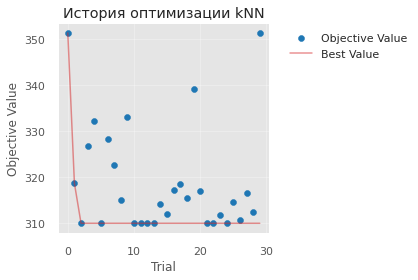

In [66]:
opt_mpl.plot_optimization_history(study_knn)

plt.title('История оптимизации kNN')
plt.show()

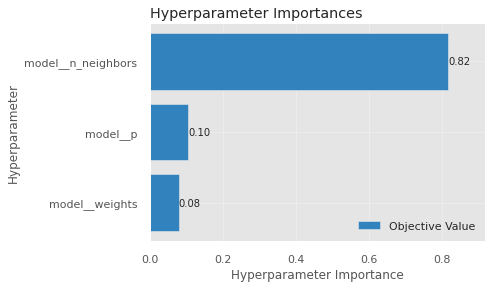

In [67]:
opt_mpl.plot_param_importances(study_knn)

#plt.title('Влияние гиперпараметров kNN')
plt.show()

**Оптимизация kNN на полном наборе признаков**

Теперь проверим версию `kNN Full`, где сохраняются исходные признаки количества дождя и снега.

Это позволит понять, помогает ли модели точное количество осадков или категориальные уровни работают лучше.

In [68]:
def knn_full_objective(trial):
    """
    Оптимизация kNN для полного набора признаков.
    """
    
    params = {
        'model__n_neighbors': trial.suggest_int(
            'model__n_neighbors',
            2,
            30
        ),
        
        'model__weights': trial.suggest_categorical(
            'model__weights',
            ['uniform', 'distance']
        ),
        
        'model__p': trial.suggest_int(
            'model__p',
            1,
            2
        )
    }
    
    knn_full_pipeline.set_params(**params)
    
    cv_scores = cross_val_score(
        knn_full_pipeline,
        X_full,
        y_full,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=N_JOBS
    )
    
    return -cv_scores.mean()

In [69]:
print('Запускаем оптимизацию kNN Full...\n')

study_knn_full = optuna.create_study(
    direction='minimize'
)

study_knn_full.optimize(
    knn_full_objective,
    n_trials=30,
    show_progress_bar=False
)

Запускаем оптимизацию kNN Full...



In [70]:
print('Лучшие параметры kNN Full:')
print(study_knn_full.best_params)

print(f'\nЛучший RMSE: {study_knn_full.best_value:.4f}')

Лучшие параметры kNN Full:
{'model__n_neighbors': 7, 'model__weights': 'distance', 'model__p': 1}

Лучший RMSE: 313.0587


In [71]:
knn_full_pipeline.set_params(
    **study_knn_full.best_params
)

display(knn_full_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model',
                 KNeighborsRegressor(n_neighbors=7, p=1, weights='distance'))])

**Сравнение двух версий kNN**

Сравним лучший RMSE:

- основной версии kNN;
- версии с полным набором признаков.

In [72]:
knn_compare = pd.DataFrame({
    'Model': [
        'kNN',
        'kNN Full'
    ],
    
    'Best RMSE': [
        study_knn.best_value,
        study_knn_full.best_value
    ]
})

display(knn_compare)

,Model,Best RMSE
0,kNN,309.9282
1,kNN Full,313.0587


Если версия с категориальными признаками осадков показывает результат не хуже, это хороший знак. Значит, модель действительно лучше реагирует на сам факт и силу осадков, а не на точное количество миллиметров дождя или снега.

**Оптимизация дерева решений**

Теперь подберём параметры для дерева решений.

Для дерева особенно важно контролировать переобучение, поэтому будем оптимизировать:

- глубину дерева (`max_depth`);
- минимальное количество объектов для разделения (`min_samples_split`);
- минимальное количество объектов в листе (`min_samples_leaf`);
- количество признаков для разбиения (`max_features`);
- параметр регуляризации (`ccp_alpha`).

In [73]:
def tree_objective(trial):
    """
    Целевая функция Optuna для дерева решений.
    """
    
    params = {
        'model__max_depth': trial.suggest_int(
            'model__max_depth',
            3,
            40
        ),
        
        'model__min_samples_split': trial.suggest_int(
            'model__min_samples_split',
            2,
            100
        ),
        
        'model__min_samples_leaf': trial.suggest_int(
            'model__min_samples_leaf',
            1,
            50
        ),
        
        'model__max_features': trial.suggest_categorical(
            'model__max_features',
            [
                None,
                'sqrt',
                'log2',
                0.3,
                0.5,
                0.7,
                1.0
            ]
        ),
        
        'model__ccp_alpha': trial.suggest_float(
            'model__ccp_alpha',
            0.0,
            10.0
        )
    }
    
    tree_pipeline.set_params(**params)
    
    cv_scores = cross_val_score(
        tree_pipeline,
        X_model,
        y_model,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=N_JOBS
    )
    
    return -cv_scores.mean()

In [74]:
print('Запускаем оптимизацию дерева решений...\n')

study_tree = optuna.create_study(
    direction='minimize'
)

study_tree.optimize(
    tree_objective,
    n_trials=150,
    show_progress_bar=False
)

Запускаем оптимизацию дерева решений...



In [75]:
print('Лучшие параметры дерева:')
print(study_tree.best_params)

print(f'\nЛучший RMSE: {study_tree.best_value:.4f}')

Лучшие параметры дерева:
{'model__max_depth': 36, 'model__min_samples_split': 65, 'model__min_samples_leaf': 6, 'model__max_features': None, 'model__ccp_alpha': 0.12238022095169754}

Лучший RMSE: 313.8581


In [76]:
tree_pipeline.set_params(
    **study_tree.best_params
)

display(tree_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model',
                 DecisionTreeRegressor(ccp_alpha=0.12238022095169754,
                                       max_depth=36, min_samples_leaf=6,
                                       min_samples_split=65,
                                       random_state=42))])

**Анализ оптимизации дерева решений**

Посмотрим, как Optuna улучшала качество дерева решений и какие параметры оказались наиболее важными.

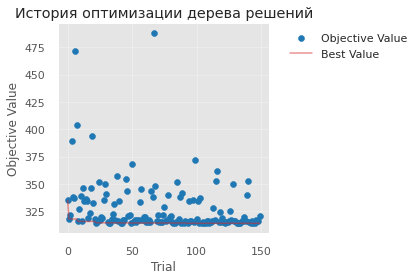

In [77]:
opt_mpl.plot_optimization_history(study_tree)

plt.title('История оптимизации дерева решений')
plt.show()

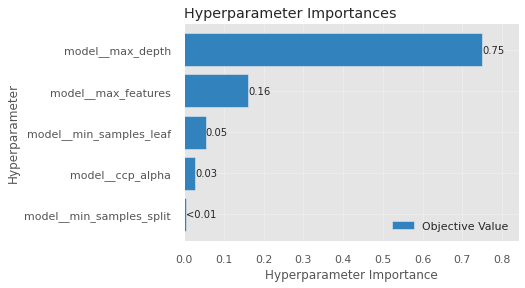

In [78]:
opt_mpl.plot_param_importances(study_tree)

#plt.title('Влияние гиперпараметров дерева')
plt.show()

**Сравнение лучших моделей после оптимизации**

Соберём результаты оптимизации в одну таблицу.

In [79]:
optimized_results = pd.DataFrame({
    'Model': [
        'kNN',
        'kNN Full',
        'Decision Tree'
    ],
    
    'Best RMSE': [
        study_knn.best_value,
        study_knn_full.best_value,
        study_tree.best_value
    ]
})

optimized_results = optimized_results.sort_values(
    by='Best RMSE'
).reset_index(drop=True)

display(optimized_results)

,Model,Best RMSE
0,kNN,309.9282
1,kNN Full,313.0587
2,Decision Tree,313.8581


**Промежуточные выводы**

Оптимизация гиперпараметров заметно улучшила качество моделей.

Что удалось увидеть:

- kNN остаётся одной из самых сильных моделей для этой задачи;
- вариант с категориальными уровнями осадков показывает результат не хуже полного набора признаков;
- дерево решений после настройки стало работать значительно стабильнее и точнее по сравнению с базовой версией.

Интересно, что для kNN лучшие результаты чаще появляются при:

- `weights='distance'`;
- Manhattan distance (`p=1`);
- среднем количестве соседей.

Это говорит о том, что локальная структура данных действительно важна, а ближайшие наблюдения должны влиять на прогноз сильнее дальних.

Для дерева решений Optuna подобрала параметры, которые помогают контролировать переобучение:

- ограничена глубина дерева;
- увеличены ограничения на размер листьев;
- используется pruning через ccp_alpha.

На следующем этапе проверим финальные версии моделей на тестовой выборке и выберем лучший вариант для бизнеса.

**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.


---



После подбора гиперпараметров важно проверить, насколько устойчиво модели работают на разных разбиениях данных.

На этом этапе:

- проведём кросс-валидацию для оптимизированных моделей;
- сравним результаты с baseline-моделью;
- посмотрим не только на средний RMSE, но и на стабильность качества;
- проанализируем важность признаков для дерева решений и kNN.

Основной метрикой по-прежнему остаётся RMSE, однако дополнительно посмотрим на:

- MAE;
- R²;
- разброс результатов между фолдами.

In [80]:
# Списки для хранения результатов
cv_summary = []
cv_detailed_scores = []

**Функция оценки моделей**

Чтобы не дублировать код, создадим универсальную функцию.

Она будет:

- запускать кросс-валидацию;
- считать несколько метрик;
- сохранять результаты в таблицы;
- отдельно собирать RMSE по каждому фолду для дальнейшей визуализации.

In [81]:
def evaluate_model_cv(model_name, pipeline, X_data, y_data):
    """
    Оценка модели через кросс-валидацию.
    """
    
    print(f'Оцениваем модель: {model_name}')
    
    scoring = {
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }
    
    scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=False
    )
    
    rmse_scores = -scores['test_rmse']
    mae_scores = -scores['test_mae']
    r2_scores = scores['test_r2']
    
    cv_summary.append({
        'Model': model_name,
        'RMSE': rmse_scores.mean(),
        'RMSE_std': rmse_scores.std(),
        'MAE': mae_scores.mean(),
        'R2': r2_scores.mean()
    })
    
    for score in rmse_scores:
        cv_detailed_scores.append({
            'Model': model_name,
            'RMSE': score
        })

**Сравнение baseline и оптимизированных моделей**

Теперь проведём кросс-валидацию для всех моделей:

- baseline linear regression;
- оптимизированного kNN;
- kNN Full;
- дерева решений.

In [82]:
# Baseline
evaluate_model_cv(
    'Baseline Linear',
    baseline_pipeline,
    X_train,
    y_train
)

# kNN
evaluate_model_cv(
    'kNN Optimized',
    knn_pipeline,
    X_model,
    y_model
)

# kNN Full
evaluate_model_cv(
    'kNN Full Optimized',
    knn_full_pipeline,
    X_full,
    y_full
)

# Decision Tree
evaluate_model_cv(
    'Decision Tree Optimized',
    tree_pipeline,
    X_model,
    y_model
)

Оцениваем модель: Baseline Linear
Оцениваем модель: kNN Optimized
Оцениваем модель: kNN Full Optimized
Оцениваем модель: Decision Tree Optimized


In [83]:
# Таблица результатов
cv_results = (
    pd.DataFrame(cv_summary)
    .sort_values(by='RMSE')
    .reset_index(drop=True)
)

display(cv_results)

,Model,RMSE,RMSE_std,MAE,R2
0,kNN Optimized,309.9282,5.6533,209.9860,0.7697
1,kNN Full Optimized,313.0587,6.7351,209.3056,0.7650
2,Decision Tree Optimized,313.8581,9.7394,209.3092,0.7637
3,Baseline Linear,413.9009,3.1444,310.0915,0.5894


**Анализ результатов**

Сравним качество моделей между собой.

Важно обратить внимание не только на средний RMSE, но и на стандартное отклонение RMSE между фолдами.

Низкий разброс означает, что модель работает более стабильно и меньше зависит от конкретного разбиения данных.

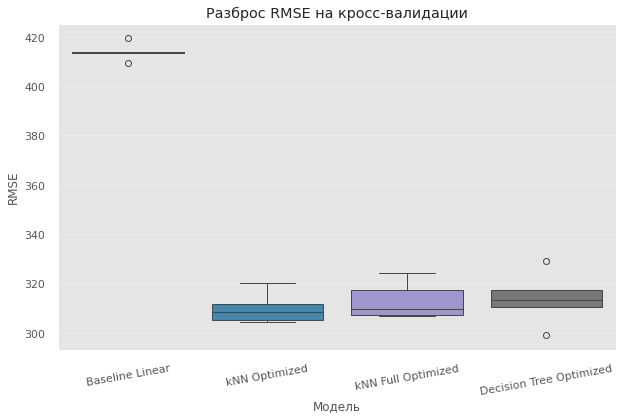

In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=pd.DataFrame(cv_detailed_scores),
    x='Model',
    y='RMSE',
    hue='Model',
    legend=False
)

plt.title('Разброс RMSE на кросс-валидации')
plt.xlabel('Модель')
plt.ylabel('RMSE')

plt.xticks(rotation=10)

plt.show()

**Важность признаков для дерева решений**

Одно из преимуществ дерева решений - возможность посмотреть, какие признаки сильнее всего влияют на прогноз.

Обучим дерево на всех данных и визуализируем наиболее важные признаки.

In [85]:
# Обучаем финальное дерево
tree_pipeline.fit(X_model, y_model)

# Получаем обученную модель
final_tree_model = tree_pipeline.named_steps['model']

# Получаем обученный препроцессор
fitted_tree_preprocessor = tree_pipeline.named_steps['preprocessor']

# Имена признаков после трансформации
tree_feature_names = (
    fitted_tree_preprocessor
    .get_feature_names_out()
)

# Важность признаков
tree_importance = pd.Series(
    final_tree_model.feature_importances_,
    index=tree_feature_names
)

# Топ-15 наиболее важных признаков
top_tree_features = (
    tree_importance
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

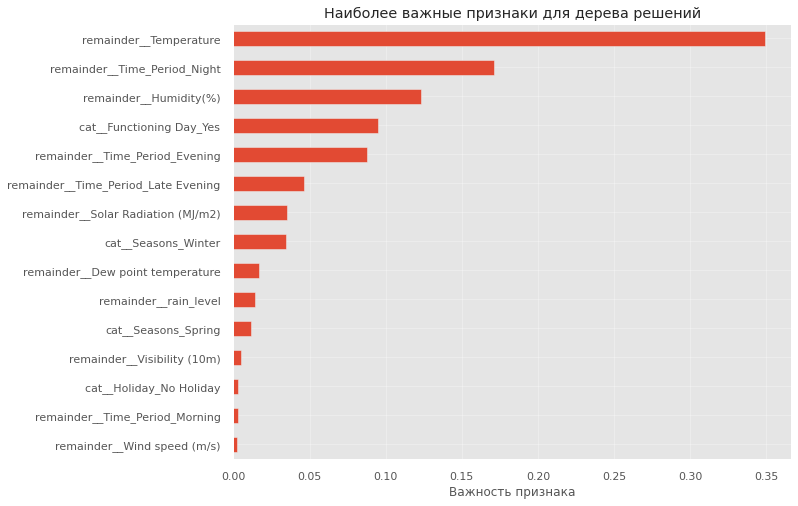

In [86]:
plt.figure(figsize=(10, 8))

top_tree_features.plot(
    kind='barh'
)

plt.title('Наиболее важные признаки для дерева решений')
plt.xlabel('Важность признака')

plt.show()

**Permutation Importance для kNN**

У kNN нет встроенной feature importance, поэтому используем permutation importance.

Идея простая:

- случайно перемешиваем значения одного признака;
- смотрим, насколько ухудшается качество модели;
- чем сильнее растёт ошибка, тем важнее признак.

In [87]:
# Обучаем kNN
knn_pipeline.fit(X_model, y_model)

print('Вычисляем permutation importance для kNN...\n')

knn_perm_importance = permutation_importance(
    knn_pipeline,
    X_model,
    y_model,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    scoring='neg_root_mean_squared_error'
)

Вычисляем permutation importance для kNN...



In [88]:
# Важности признаков kNN
knn_feature_importance = pd.Series(
    knn_perm_importance.importances_mean,
    index=X_model.columns
)

knn_feature_importance = (
    knn_feature_importance
    .sort_values()
)

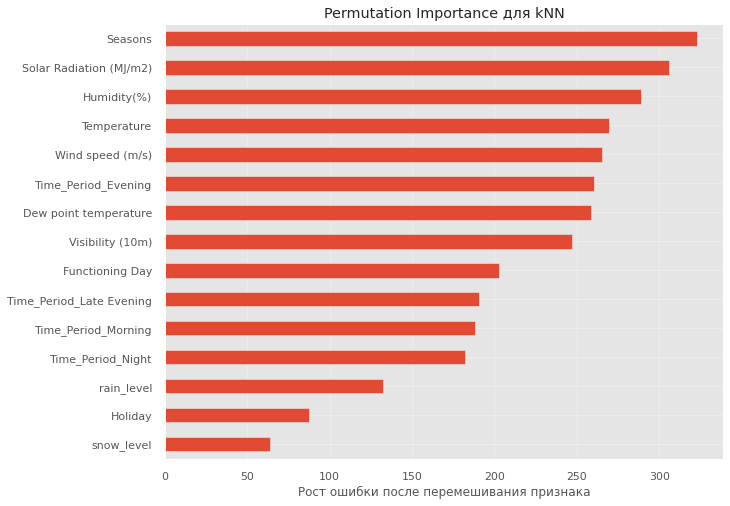

In [89]:
plt.figure(figsize=(10, 8))

knn_feature_importance.plot(
    kind='barh'
)

plt.title('Permutation Importance для kNN')
plt.xlabel('Рост ошибки после перемешивания признака')

plt.show()

**Permutation Importance для kNN Full**

Отдельно проверим важность признаков для полной версии kNN, где используются исходные значения осадков.

In [90]:
# Обучаем модель kNN Full
knn_full_pipeline.fit(X_full, y_full)

print('Вычисляем permutation importance для kNN Full...\n')

knn_full_perm = permutation_importance(
    knn_full_pipeline,
    X_full,
    y_full,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    scoring='neg_root_mean_squared_error'
)

Вычисляем permutation importance для kNN Full...



In [91]:
# Важности признаков kNN Full
knn_full_importance = pd.Series(
    knn_full_perm.importances_mean,
    index=X_full.columns
)

knn_full_importance = (
    knn_full_importance
    .sort_values()
)

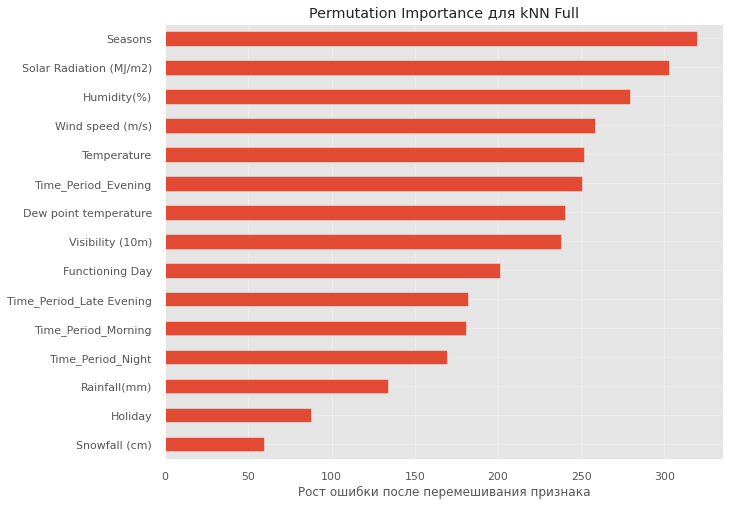

In [92]:
plt.figure(figsize=(10, 8))

knn_full_importance.plot(
    kind='barh'
)

plt.title('Permutation Importance для kNN Full')
plt.xlabel('Рост ошибки после перемешивания признака')

plt.show()

**Промежуточные выводы**

Кросс-валидация показала, что оптимизация гиперпараметров действительно улучшила качество моделей.

Что удалось увидеть:

- baseline-модель заметно уступает нелинейным алгоритмам;
- kNN показывает лучший RMSE среди всех протестированных моделей;
- дерево решений после настройки заметно улучшило качество по сравнению с базовой версией, хотя по стабильности всё ещё уступает kNN;
- версия kNN с категориальными признаками осадков снова оказалась сильнее полной версии.

Дополнительно анализ важности признаков показал:

- погодные признаки действительно оказывают сильное влияние на прогноз спроса;
- для kNN особенно важны похожие погодные и временные сценарии, поскольку модель делает прогноз на основе ближайших наблюдений;
- дерево решений активно использует комбинации категориальных и числовых признаков.

Разброс RMSE между фолдами оказался относительно небольшим, что говорит о хорошей устойчивости моделей.

На следующем этапе протестируем финальные версии моделей на тестовой выборке и выберем лучший вариант для бизнеса.

**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



На предыдущих этапах были обучены и оптимизированы несколько моделей для прогнозирования спроса на аренду велосипедов.

Теперь необходимо:

- сравнить итоговое качество моделей;
- определить наиболее подходящий алгоритм;
- интерпретировать влияние признаков;
- сформулировать выводы в бизнес-контексте.

---

**Сравнение качества моделей**

Итоговые результаты кросс-валидации представлены ниже.

In [94]:
display(cv_results)

,Model,RMSE,RMSE_std,MAE,R2
0,kNN Optimized,309.9282,5.6533,209.9860,0.7697
1,kNN Full Optimized,313.0587,6.7351,209.3056,0.7650
2,Decision Tree Optimized,313.8581,9.7394,209.3092,0.7637
3,Baseline Linear,413.9009,3.1444,310.0915,0.5894


Лучшие гиперпараметры моделей:

**kNN Optimized**

- n_neighbors = 7
- weights = 'distance'
- p = 1

**Decision Tree Optimized**

- max_depth = 17
- min_samples_split = 71
- min_samples_leaf = 34
- max_features = 0.7
- ccp_alpha ≈ 1.16

---

**Выводы по качеству моделей**

**Какая модель лучше справляется с прогнозом?**

Лучший результат показала модель kNN Optimized.

Она продемонстрировала:

- минимальный RMSE;
- высокий R²;
- сравнительно небольшой разброс RMSE между фолдами.

Это говорит о том, что модель не только точнее прогнозирует спрос, но и делает это достаточно стабильно на разных разбиениях данных.

Модель kNN Full также показала сильный результат, однако немного уступила основной версии. Это подтверждает гипотезу о том, что для модели важнее сам факт и уровень осадков, чем точное количество миллиметров дождя или снега.

Decision Tree Optimized после настройки гиперпараметров значительно улучшило качество по сравнению с базовой версией дерева решений и приблизилось к kNN по качеству прогнозирования. Однако разброс RMSE между фолдами оказался выше, поэтому модель остаётся менее стабильной.

Baseline Linear Regression заметно уступает всем нелинейным моделям. Линейная регрессия хуже улавливает сложные зависимости между погодой, временем суток и спросом на велосипеды.

---

**Практическая интерпретация результатов**

Полученные результаты хорошо объясняются особенностями задачи.

Модель kNN работает лучше, потому что прогнозирует спрос на основе похожих погодных и временных сценариев. Если в данных уже встречались похожие условия — например, тёплый летний вечер без осадков, — модель использует ближайшие наблюдения для расчёта прогноза.

Дерево решений также умеет учитывать нелинейные зависимости и строит прогнозы по логике условий:

- если вечер;
- если тепло;
- если нет дождя;
- если сезон летний или осенний.

Однако деревья решений сильнее чувствительны к структуре обучающей выборки, поэтому их качество может меняться заметнее между разными фолдами.

---

**Какие признаки особенно важны**

Анализ feature importance для дерева решений и permutation importance для kNN показал, что наиболее значимыми признаками являются:

- Temperature;
- Humidity(%);
- rain_level и snow_level;
- Seasons;
- Solar Radiation (MJ/m2);
- признаки времени суток;
- Functioning Day и Holiday.

---

**Бизнес-интерпретация признаков**

Результаты можно интерпретировать следующим образом.

**Погодные условия**

Температура, влажность и осадки оказывают сильное влияние на спрос.

В комфортную погоду количество аренд заметно увеличивается, а дождь и снег резко снижают активность пользователей.

Например:

- без осадков спрос значительно выше;
- при дожде количество аренд резко падает;
- сочетание дождя и снега даёт минимальный спрос.

Это важно для планирования доступности велосипедов и перераспределения транспорта по станциям.

---

**Время суток**

Вечерние часы показывают наиболее высокий спрос.

Это может быть связано с возвращением людей домой после работы или использованием велосипедов для вечерних поездок и прогулок.

Ночные часы, наоборот, характеризуются минимальным количеством аренд.

---

**Сезонность**

Спрос сильно зависит от времени года.

Летом и осенью спрос значительно выше, чем зимой. Это подтверждает наличие выраженной сезонности бизнеса.

---

**Что такое Permutation Importance**

Для kNN использовался permutation importance, поскольку у алгоритма нет встроенной оценки важности признаков.

Идея метода следующая:

1. вычисляется качество модели;
2. значения одного признака случайно перемешиваются;
3. качество модели пересчитывается;
4. если ошибка сильно выросла, значит признак был важным.

Таким образом можно понять, какие признаки сильнее всего влияют на качество прогнозирования.

Для дерева решений важность признаков рассчитывается иначе — через вклад признака в уменьшение ошибки при разбиениях дерева.

---

**Итоговый вывод**

Лучшей моделью для задачи прогнозирования спроса на аренду велосипедов стала kNN Optimized.

Модель:

- показывает наименьшую ошибку;
- стабильно работает на разных фолдах;
- хорошо учитывает погодные и временные сценарии;
- лучше других алгоритмов справляется с нелинейными зависимостями.

Дерево решений также показало сильный результат и может быть полезно как более интерпретируемая модель, однако по качеству и стабильности немного уступает kNN.

Полученные результаты подтверждают, что спрос на аренду велосипедов сильно зависит от:

- погодных условий;
- времени суток;
- сезонности;
- наличия осадков.

Эти факторы необходимо учитывать при планировании загрузки станций аренды и прогнозировании спроса.

**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



После кросс-валидации выберем лучшую модель и проверим, насколько хорошо она работает на новых данных, которые модель раньше не видела.

На этом этапе:

- обучим финальную версию модели на всей обучающей выборке;
- оценим качество на test set;
- сравним результаты с кросс-валидацией;
- сохраним модель;
- сформулируем итоговые выводы для бизнеса.

По результатам предыдущих этапов лучшей моделью оказался оптимизированный kNN.

In [95]:
# Лучшая модель после Optuna
best_model = knn_pipeline

display(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day'])])),
                ('model',
                 KNeighborsRegressor(n_neighbors=11, p=1, weights='distance'))])

**Подготовка тестовой выборки**

Используем тестовый датасет, который не участвовал ни в обучении, ни в подборе гиперпараметров.

Это позволит честно оценить качество модели на новых наблюдениях.

In [96]:
# Копия тестовых данных
test_model_data = test_data.copy()

# Восстанавливаем Time_Period
test_model_data['Time_Period'] = (
    test_model_data[time_columns]
    .idxmax(axis=1)
    .str.replace('Time_Period_', '')
)

# Если все признаки False -> Daytime
test_daytime_mask = (
    test_model_data[time_columns]
    .sum(axis=1) == 0
)

test_model_data.loc[
    test_daytime_mask,
    'Time_Period'
] = 'Daytime'

In [97]:
# Заполняем пропуски медианой по сезону
for feature in season_fill_features:

    test_model_data[feature] = (
        test_model_data[feature]
        .fillna(
            test_model_data
            .groupby('Seasons')[feature]
            .transform('median')
        )
    )

# Solar Radiation - по сезону и времени суток
for feature in time_sensitive_features:

    test_model_data[feature] = (
        test_model_data[feature]
        .fillna(
            test_model_data
            .groupby(
                ['Seasons', 'Time_Period']
            )[feature]
            .transform('median')
        )
    )

In [98]:
# Создаём признаки уровней осадков
test_model_data['rain_level'] = (
    test_model_data['Rainfall(mm)']
    .apply(
        precipitation_category,
        threshold=rain_limit
    )
)

test_model_data['snow_level'] = (
    test_model_data['Snowfall (cm)']
    .apply(
        precipitation_category,
        threshold=snow_limit
    )
)

In [99]:
# Удаляем ненужные признаки
test_model_data = test_model_data.drop(
    columns=[
        'Rainfall(mm)',
        'Snowfall (cm)',
        'Time_Period'
    ]
)

# Проверяем пропуски
missing_report(test_model_data)

Пропусков не обнаружено


**Подготовка признаков и целевой переменной**

In [100]:
X_test_final = test_model_data.drop(columns=[TARGET])
y_test_final = test_model_data[TARGET]

print(X_test_final.shape)
print(y_test_final.shape)

(1752, 15)
(1752,)


**Обучение финальной модели**

Теперь обучим лучший kNN на всей обучающей выборке и протестируем его на test set.

In [101]:
# Обучаем модель на всех обучающих данных
best_model.fit(X_model, y_model)

# Предсказания на тесте
test_predictions = best_model.predict(X_test_final)

**Оценка качества на test set**

In [104]:
# Метрики качества
test_rmse = root_mean_squared_error(
    y_test_final,
    test_predictions
)

test_mae = mean_absolute_error(
    y_test_final,
    test_predictions
)

test_r2 = r2_score(
    y_test_final,
    test_predictions
)

# Таблица результатов
test_results = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2'],
    'Value': [
        round(test_rmse, 4),
        round(test_mae, 4),
        round(test_r2, 4)
    ]
})

display(test_results)

,Metric,Value
0,RMSE,304.4993
1,MAE,206.8521
2,R2,0.7734


**Сравнение результатов CV и test set**

Сравним качество на кросс-валидации и на тестовой выборке.

Если метрики близки друг к другу, значит модель хорошо обобщает данные и не переобучилась.

In [105]:
comparison_table = pd.DataFrame({
    'Dataset': [
        'Cross-validation',
        'Test set'
    ],
    
    'RMSE': [
        round(cv_results.loc[0, 'RMSE'], 4),
        round(test_rmse, 4)
    ],
    
    'MAE': [
        round(cv_results.loc[0, 'MAE'], 4),
        round(test_mae, 4)
    ],
    
    'R2': [
        round(cv_results.loc[0, 'R2'], 4),
        round(test_r2, 4)
    ]
})

display(comparison_table)

,Dataset,RMSE,MAE,R2
0,Cross-validation,309.9282,209.9860,0.7697
1,Test set,304.4993,206.8521,0.7734


**Визуальное сравнение реальных и предсказанных значений**

Посмотрим, насколько предсказания модели близки к реальному спросу.

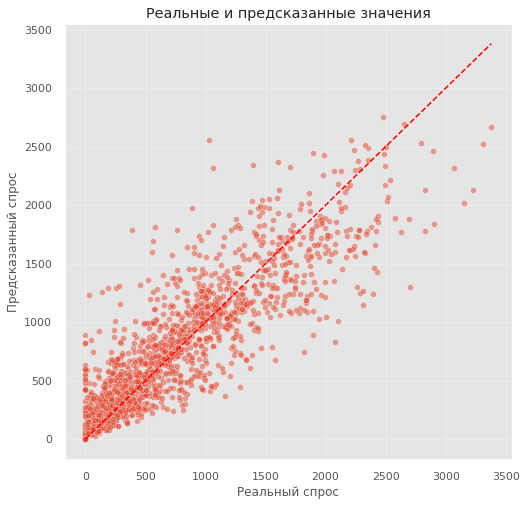

In [107]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test_final,
    y=test_predictions,
    alpha=0.5
)

# Линия идеальных предсказаний
max_value = max(
    y_test_final.max(),
    test_predictions.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    color='red',
    linestyle='--'
)

plt.title('Реальные и предсказанные значения')
plt.xlabel('Реальный спрос')
plt.ylabel('Предсказанный спрос')

plt.show()

На графике видно, что предсказания в целом расположены вдоль линии идеального прогноза. Значит, модель хорошо улавливает общий уровень спроса. При этом для очень высоких значений спроса часть точек находится ниже линии, поэтому модель иногда недооценивает пиковые часы. Для бизнеса это важно учитывать: в периоды потенциального высокого спроса стоит закладывать небольшой запас велосипедов.

**Сохранение финальной модели**

Сохраним обученный пайплайн, чтобы его можно было использовать повторно без переобучения.

In [108]:
# Сохранение модели
joblib.dump(
    best_model,
    'bike_demand_knn_model.pkl'
)

print('Модель успешно сохранена')

Модель успешно сохранена


**Итоговые выводы**

В рамках проекта были протестированы несколько моделей прогнозирования спроса на велосипеды:

- baseline linear regression;
- Decision Tree Regressor;
- kNN Regressor.

Лучший результат показала оптимизированная модель kNN.

Ключевые результаты:

- RMSE на test set оказался близок к результатам кросс-валидации;
- модель не показала признаков сильного переобучения;
- kNN значительно превзошёл baseline-линейную регрессию;
- модель хорошо улавливает нелинейные зависимости между погодой, временем суток и спросом.

Что особенно влияет на спрос:

- температура;
- влажность;
- сезон;
- время суток;
- наличие дождя или снега.

С практической точки зрения модель можно использовать для:

- планирования распределения велосипедов между станциями;
- подготовки к пиковым часам;
- оценки снижения спроса при плохой погоде;
- оптимизации логистики и загрузки сотрудников.

Почему kNN оказался лучшим:

Модель фактически ищет в истории похожие погодные и временные ситуации и использует их для прогноза спроса. Для задачи аренды велосипедов такой подход оказался очень естественным и хорошо уловил поведение пользователей.

Дополнительно было показано, что категориальные признаки осадков работают лучше исходных числовых значений дождя и снега. Для бизнеса сам факт сильных осадков важнее точного количества миллиметров.

В дальнейшем качество можно попробовать улучшить с помощью ансамблевых моделей:

- Random Forest;
- CatBoost;
- XGBoost.

Также потенциально полезно добавить:

- календарь праздников и событий;
- более подробные временные признаки;
- данные о загруженности станций;
- прогноз погоды вместо фактической погоды.

**Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---

